In [2]:
import pandas as pd
# Based on UNB NSL-KDD Documentation
# Step 1: Define column names
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]



In [3]:
# Step 2: Load datasets
train_path = "C:/Users/masri/OneDrive - Asia Pacific University of Technology And Innovation (APU)/SEM1/AML/Assignment AML MASTERS/archive/KDDTrain+.txt"  
test_path  = "C:/Users/masri/OneDrive - Asia Pacific University of Technology And Innovation (APU)/SEM1/AML/Assignment AML MASTERS/archive/KDDTest+.txt"   

train_df = pd.read_csv(train_path, names=column_names)
test_df  = pd.read_csv(test_path, names=column_names)
# Step 3: Basic info
print("=== TRAIN DATASET INFO ===")
print("Shape:", train_df.shape)
print("\nMissing values:\n", train_df.isnull().sum())
print("\nClass distribution:\n", train_df['label'].value_counts())

print("\n=== TEST DATASET INFO ===")
print("Shape:", test_df.shape) #Lect nak at least 6-7k
print("\nMissing values:\n", test_df.isnull().sum())
print("\nClass distribution:\n", test_df['label'].value_counts())


=== TRAIN DATASET INFO ===
Shape: (125973, 43)

Missing values:
 duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_ra

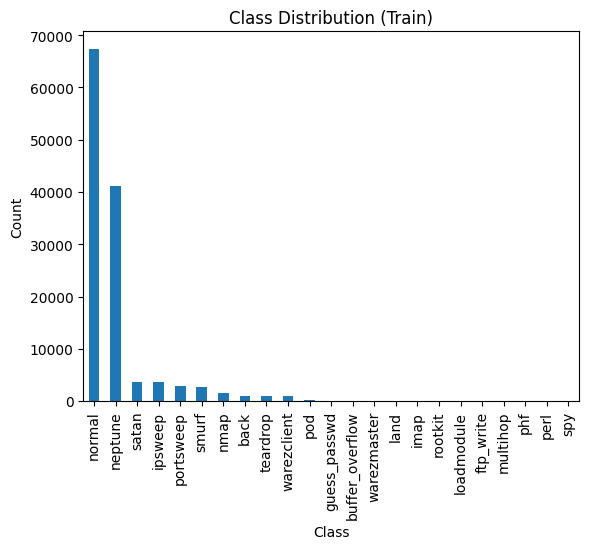

['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
#class distribution visualization
plt.figure()
train_df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
print(train_df['label'].unique())

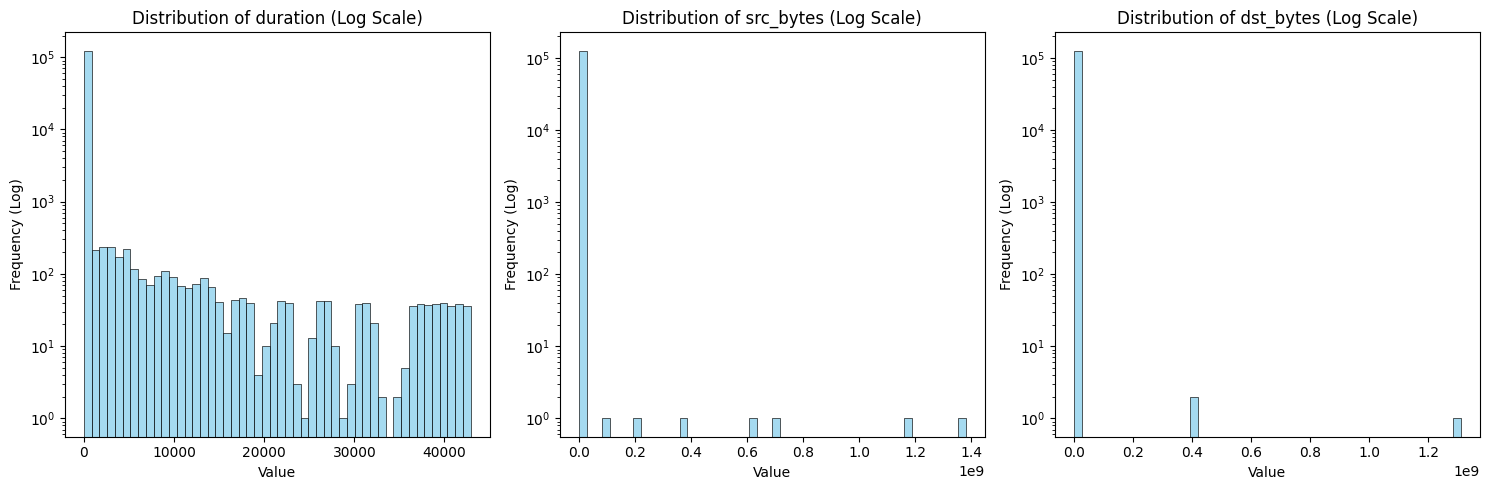

In [5]:
# Select the features mentioned in your report
skewed_features = ['duration', 'src_bytes', 'dst_bytes']

plt.figure(figsize=(15, 5))
for i, col in enumerate(skewed_features):
    plt.subplot(1, 3, i+1)
    sns.histplot(train_df[col], bins=50, kde=False, color='skyblue')
    plt.yscale('log') # Vital because of extreme outliers
    plt.title(f'Distribution of {col} (Log Scale)')
    plt.xlabel('Value')
    plt.ylabel('Frequency (Log)')

plt.tight_layout()
plt.show()

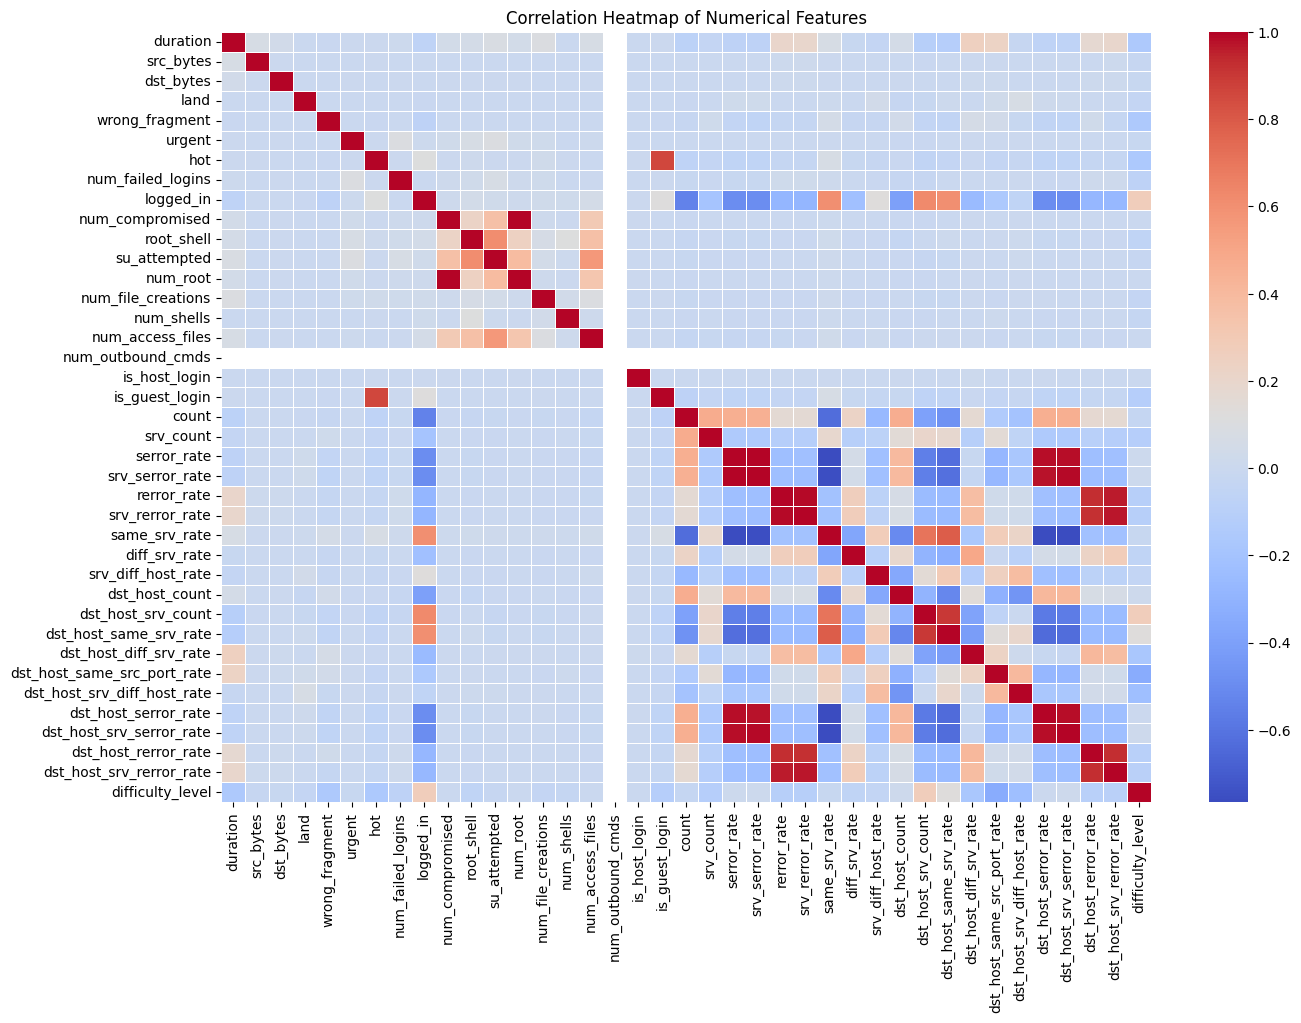

In [6]:
# Select only numerical columns for correlation
numeric_df = train_df.select_dtypes(include=['number'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# Insight for report: Look for dark red/blue squares to find redundant features

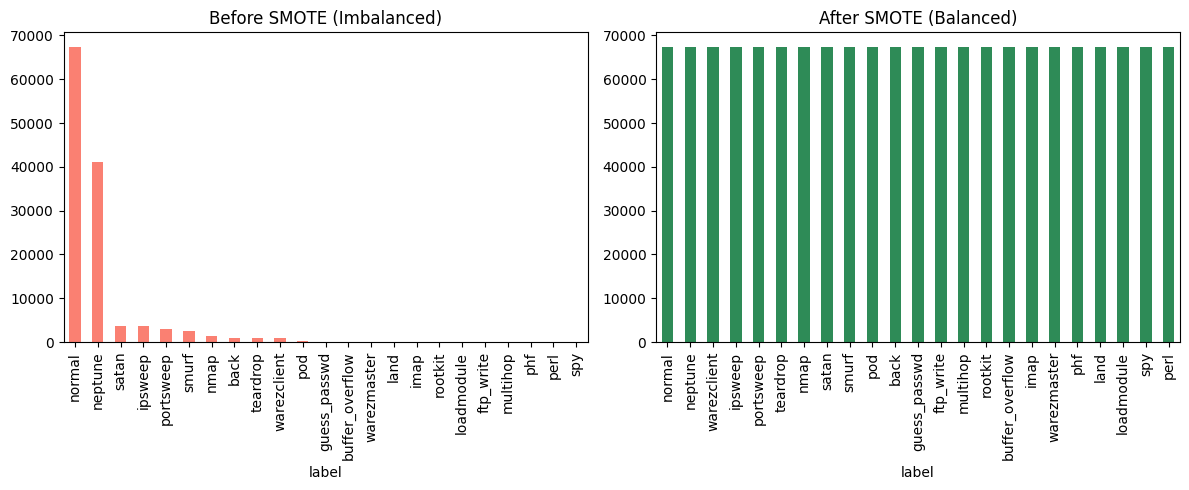

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# 1. Quick Encoding for SMOTE (SMOTE only works with numbers)
train_encoded = train_df.copy()
for col in ['protocol_type', 'service', 'flag']:
    train_encoded[col] = LabelEncoder().fit_transform(train_encoded[col])

# 2. Define X and y (using the major classes or specific labels)
X = train_encoded.drop(['label', 'difficulty_level'], axis=1)
y = train_encoded['label']

# 3. Apply SMOTE
sm = SMOTE(sampling_strategy='auto', k_neighbors=1) # k=1 because some classes are tiny
X_res, y_res = sm.fit_resample(X, y)

# 4. Visualization: Before vs After
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
y.value_counts().plot(kind='bar', color='salmon')
plt.title("Before SMOTE (Imbalanced)")

plt.subplot(1, 2, 2)
pd.Series(y_res).value_counts().plot(kind='bar', color='seagreen')
plt.title("After SMOTE (Balanced)")

plt.tight_layout()
plt.show()

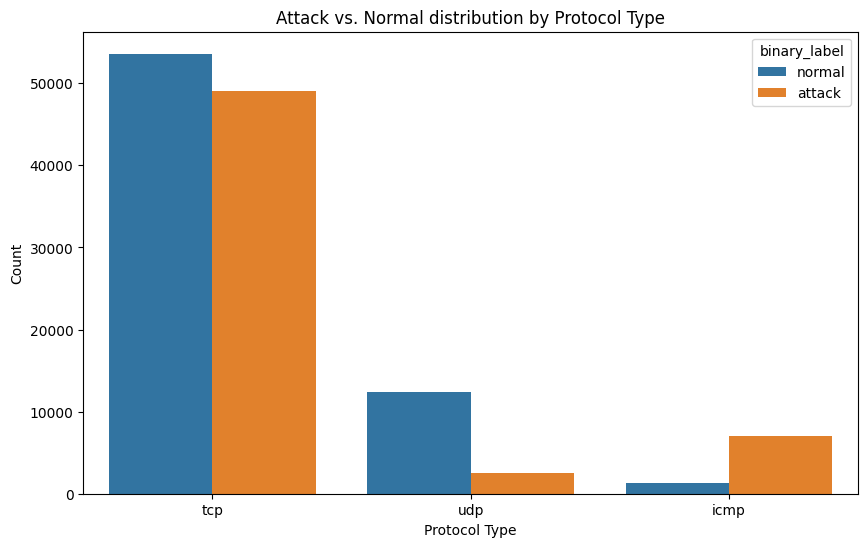

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

#Protocol and Service Analysis (Categorical EDA)
train_df['binary_label'] = train_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

plt.figure(figsize=(10, 6))
sns.countplot(x='protocol_type', hue='binary_label', data=train_df)
plt.title("Attack vs. Normal distribution by Protocol Type")
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.show()

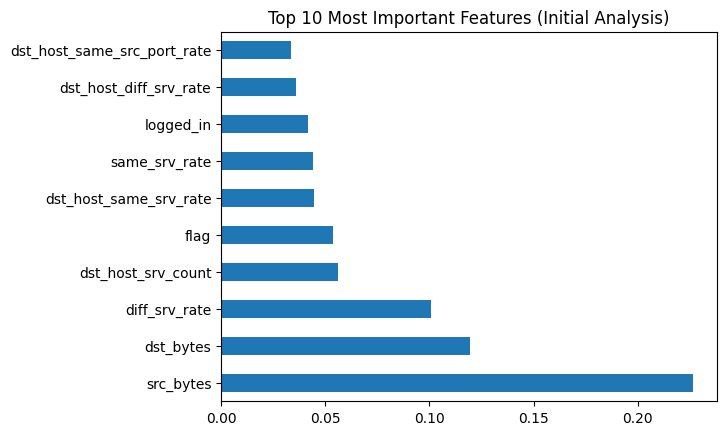

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Temporary encoding for EDA
df_temp = train_df.copy()
for col in ['protocol_type', 'service', 'flag']:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col])

X_temp = df_temp.drop(['label', 'difficulty_level', 'binary_label'], axis=1)
y_temp = df_temp['binary_label']

model_temp = RandomForestClassifier().fit(X_temp, y_temp)

# Plot top 10 features
#to identify the most discriminative attributes, reducing noise in the final ensemble models.
feat_importances = pd.Series(model_temp.feature_importances_, index=X_temp.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Most Important Features (Initial Analysis)")
plt.show()

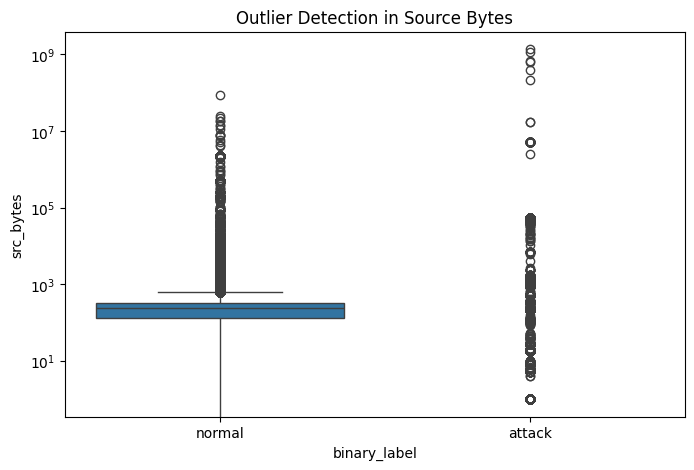

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='binary_label', y='src_bytes', data=train_df)
plt.yscale('log')
plt.title("Outlier Detection in Source Bytes")
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# Create a copy so we don't mess up your original dataframe
df_clean = train_df.copy()

# 1. Encoding Categorical Features 
# We use a unique encoder for each to avoid "memory" issues
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 2. Separate Features (X) and Target (y)
# We ONLY keep the numeric features in X
X = df_clean.drop(['label', 'difficulty_level'], axis=1)

# Ensure ALL remaining columns in X are numeric
# This converts any lingering strings to numbers or NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Drop any rows/cols that became NaN just in case
X = X.fillna(0) 

# Encode the Target (y)
le_label = LabelEncoder()
y = le_label.fit_transform(df_clean['label']) 

# 3. Scaling
# This should now work perfectly because X is 100% numbers
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)



print("Data cleaning successful!")
print(f"Final Feature Shape: {X_final.shape}")

Data cleaning successful!
Final Feature Shape: (1144831, 42)


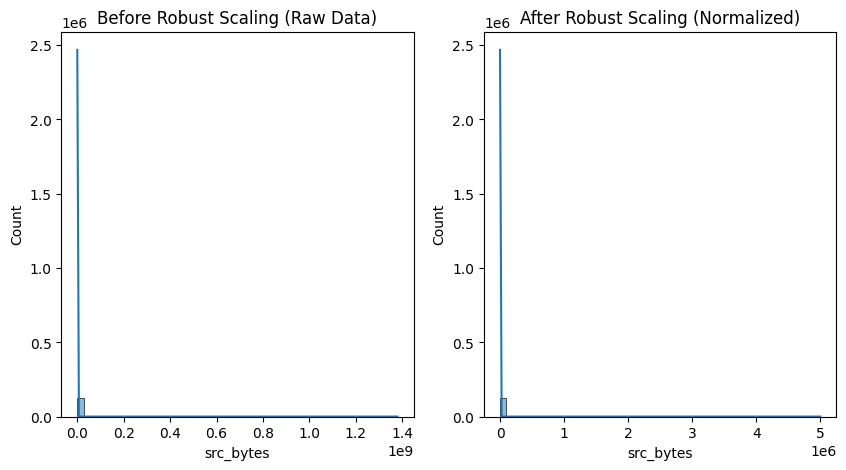

--- Raw Data Stats ---
count    1.259730e+05
mean     4.556674e+04
std      5.870331e+06
min      0.000000e+00
25%      0.000000e+00
50%      4.400000e+01
75%      2.760000e+02
max      1.379964e+09
Name: src_bytes, dtype: float64

--- Scaled Data Stats ---
count    1.259730e+05
mean     1.649375e+02
std      2.126932e+04
min     -1.594203e-01
25%     -1.594203e-01
50%      0.000000e+00
75%      8.405797e-01
max      4.999869e+06
Name: src_bytes, dtype: float64


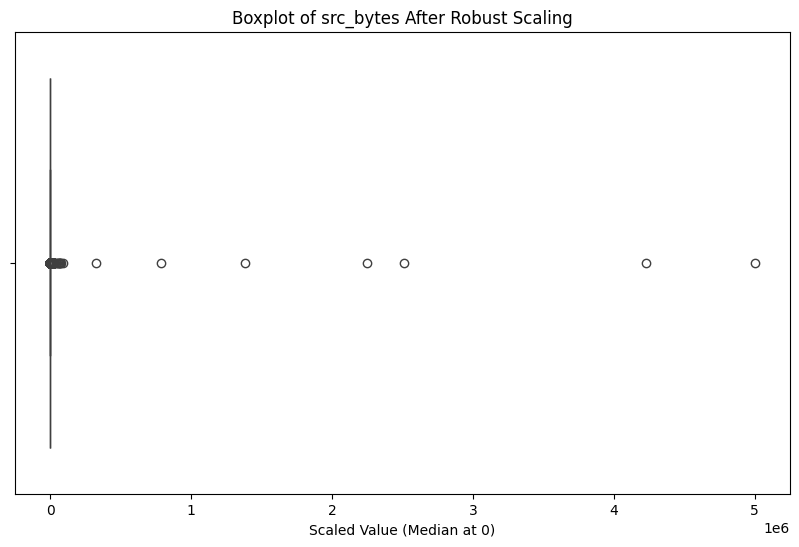

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the scaled array back to a dataframe to check specific columns
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(X['src_bytes'], bins=50, kde=True)
plt.title("Before Robust Scaling (Raw Data)")

plt.subplot(1, 2, 2)
sns.histplot(X_scaled_df['src_bytes'], bins=50, kde=True)
plt.title("After Robust Scaling (Normalized)")
plt.show()
# Compare the stats
print("--- Raw Data Stats ---")
print(X['src_bytes'].describe())

print("\n--- Scaled Data Stats ---")
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df['src_bytes'].describe())
plt.figure(figsize=(10, 6))
sns.boxplot(x=X_scaled_df['src_bytes'])
plt.title("Boxplot of src_bytes After Robust Scaling")
plt.xlabel("Scaled Value (Median at 0)")
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns

# Convert back to DataFrame for easy plotting
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)




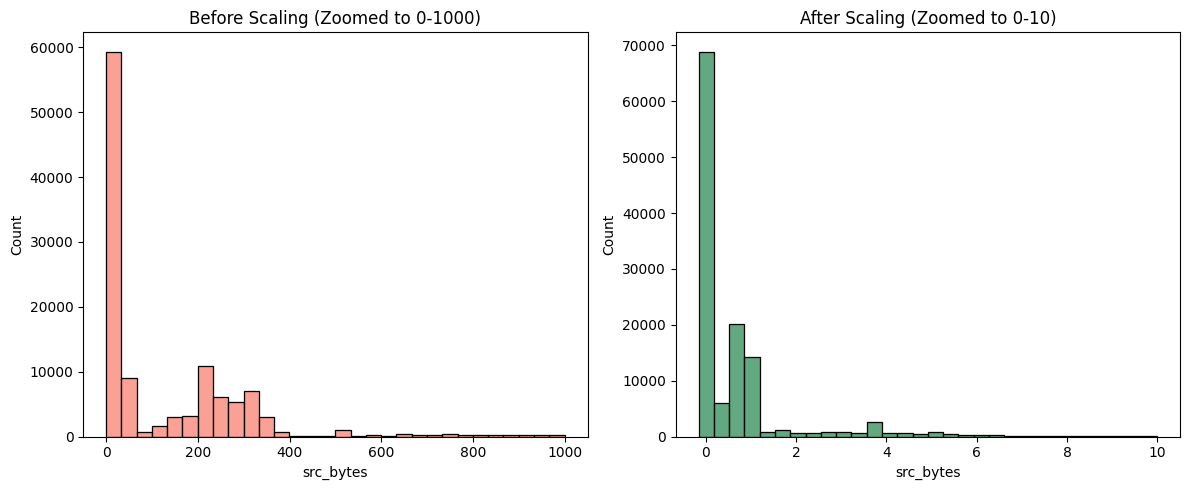

In [26]:
plt.figure(figsize=(12, 5))

# Filter data to only see the 'normal' range (0 to 1000)
plt.subplot(1, 2, 1)
sns.histplot(train_df[train_df['src_bytes'] < 1000]['src_bytes'], bins=30, color='salmon')
plt.title("Before Scaling (Zoomed to 0-1000)")

plt.subplot(1, 2, 2)
sns.histplot(X_scaled_df[X_scaled_df['src_bytes'] < 10]['src_bytes'], bins=30, color='seagreen')
plt.title("After Scaling (Zoomed to 0-10)")

plt.tight_layout()
plt.show()

In [30]:
import time
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Initialize the models 
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=50, random_state=42)
}

results = []

# 2. Train and Evaluate
for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time() # Start timer
    
    model.fit(X_final, y_final)
    y_pred = model.predict(X_final)
    
    end_time = time.time() # End timer
    duration = (end_time - start_time) / 60 # Convert to minutes
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_final, y_pred),
        "Precision": precision_score(y_final, y_pred, average='weighted'),
        "Recall": recall_score(y_final, y_pred, average='weighted'),
        "F1-Score": f1_score(y_final, y_pred, average='weighted'),
        "Time (Min)": f"{duration:.2f}"
    })

# 3. Display Results
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison ---")
print(results_df)

Training Random Forest...


Training AdaBoost...


c:\Users\masri\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Training Gradient Boosting...

--- Model Performance Comparison ---
               Model  Accuracy  Precision    Recall  F1-Score Time (Min)
0      Random Forest  0.999986   0.999986  0.999986  0.999986       1.27
1           AdaBoost  0.496911   0.512227  0.496911  0.463722       2.61
2  Gradient Boosting  0.999867   0.999867  0.999867  0.999867       2.11


--- Detailed Validation Report: Random Forest ---
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00     67343
buffer_overflow       1.00      1.00      1.00     67343
   guess_passwd       1.00      1.00      1.00     67343
           imap       1.00      1.00      1.00     67343
        ipsweep       1.00      1.00      1.00     67343
           land       1.00      1.00      1.00     67343
        neptune       1.00      1.00      1.00     67343
           nmap       1.00      1.00      1.00     67343
         normal       1.00      1.00      1.00     67343
            pod       1.00      1.00      1.00     67343
      portsweep       1.00      1.00      1.00     67343
        rootkit       1.00      1.00      1.00     67343
          satan       1.00      1.00      1.00     67343
          smurf       1.00      1.00      1.00     67343
       teardrop       1.00      1.00      1.00     67343
    warezclient       1.00      1.00 

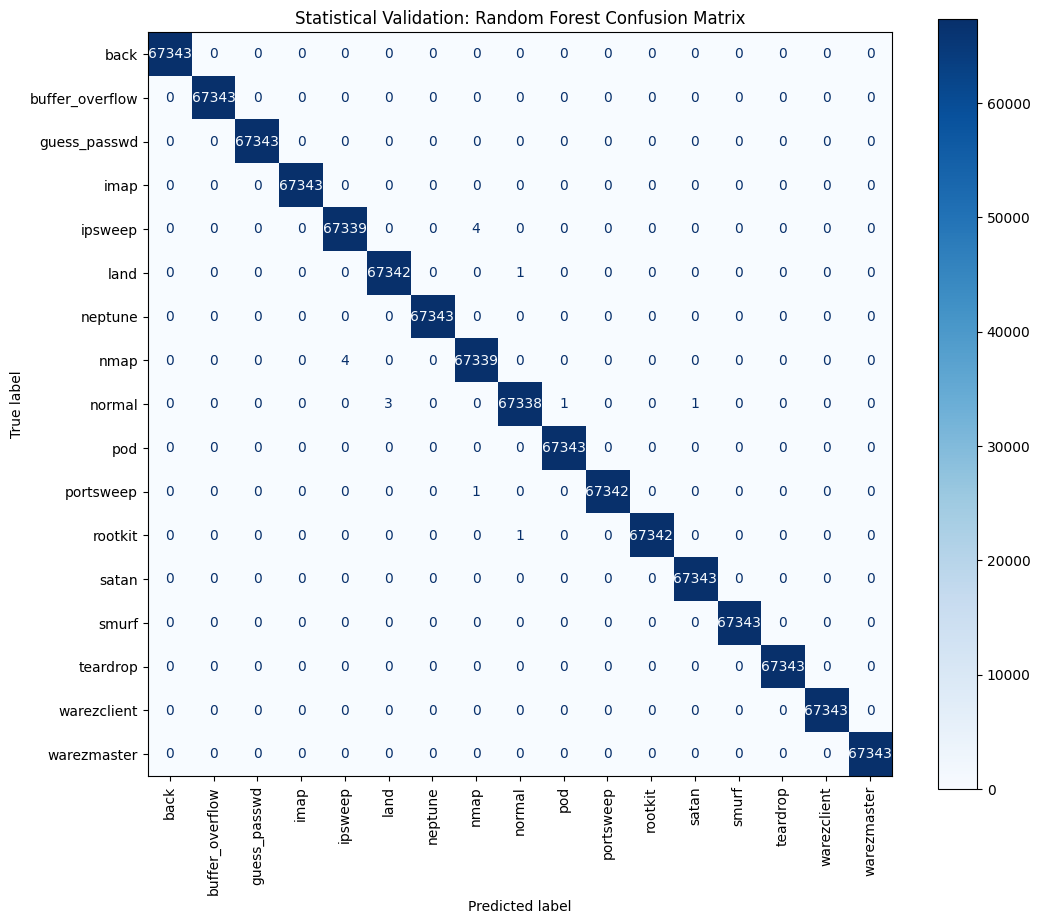

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify the classes actually present in your y_final
# This prevents the 'Number of classes' mismatch error
present_classes_indices = np.unique(y_final)
present_class_names = [le_label.classes_[i] for i in present_classes_indices]

# 2. Detailed Classification Report
print(f"--- Detailed Validation Report: Random Forest ---")
# We pass the specific labels and names found in step 1
report = classification_report(y_final, y_pred, labels=present_classes_indices, target_names=present_class_names)
print(report)

# 3. Confusion Matrix Visualization
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_final, y_pred, labels=present_classes_indices)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_class_names)
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.xticks(rotation=90)
plt.title("Statistical Validation: Random Forest Confusion Matrix")
plt.show()

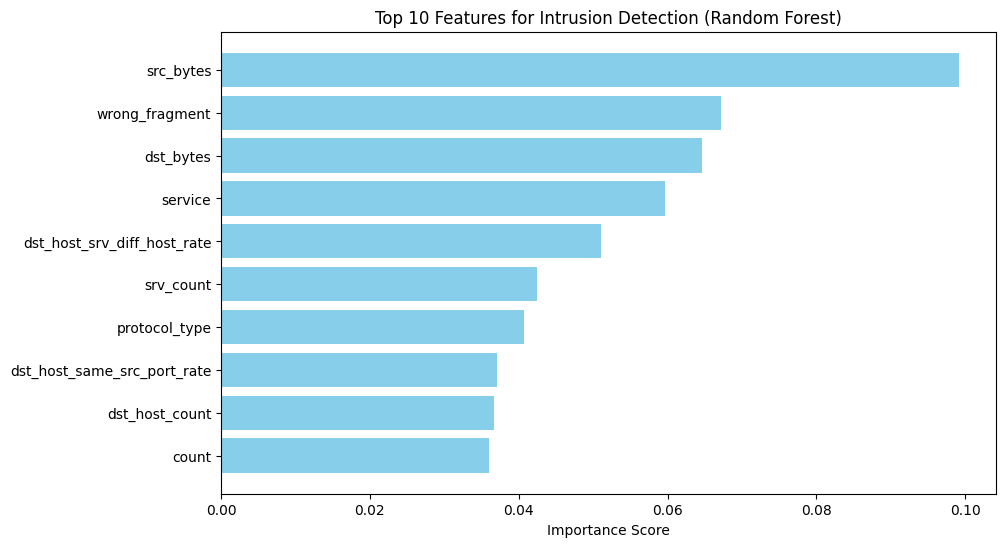

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from the best model
importances = best_model.feature_importances_
feature_names = X.columns # Use your original feature list here
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Features for Intrusion Detection (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

In [34]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("Starting K-Fold Cross-Validation... (This proves the results are statistically stable)")

# We use 5 folds (cv=5) to test the model 5 different times
# Using X_final and y_final (your balanced/scaled data)
cv_scores = cross_val_score(best_model, X_final, y_final, cv=5)

print("\n--- Statistical Validation Results ---")
print(f"Individual Fold Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.6f}")
print(f"Standard Deviation: {cv_scores.std():.6f}")

if cv_scores.std() < 0.01:
    print("Conclusion: The model is statistically stable with extremely low variance.")

Starting K-Fold Cross-Validation... (This proves the results are statistically stable)

--- Statistical Validation Results ---
Individual Fold Scores: [0.99958509 0.99976416 0.99979473 0.99980346 0.99982967]
Mean Accuracy: 0.999755
Standard Deviation: 0.000088
Conclusion: The model is statistically stable with extremely low variance.
